In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('/realistic_e_commerce_sales_data.csv')
df.head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19


## 1. Initial Inspection
Check the shape, column data types, and missing values before doing anything else.

In [23]:
print("Shape (rows, columns):", df.shape)
print()
print("Column dtypes:")
print(df.dtypes)

Shape (rows, columns): (1000, 12)

Column dtypes:
Customer ID         object
Gender              object
Region              object
Age                float64
Product Name        object
Category            object
Unit Price         float64
Quantity             int64
Total Price          int64
Shipping Fee       float64
Shipping Status     object
Order Date          object
dtype: object


In [24]:
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64


**Observation:** The dataset has 1,000 orders and 12 columns. `Region`, `Age`, and `Shipping Status` contain missing values. Since these gaps are small relative to the dataset size, we'll leave `Region` and `Shipping Status` as-is (treating missing as "Unknown" implicitly) and exclude nulls only where a specific analysis requires that column, rather than dropping rows outright.

## 2. Descriptive Statistics
Mean, median, mode, and standard deviation for every numerical column.

In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[numeric_cols].describe().T
desc['median'] = df[numeric_cols].median()
desc['mode'] = df[numeric_cols].mode().iloc[0]
desc[['mean', 'median', 'mode', 'std', 'min', 'max']]

,mean,median,mode,std,min,max
Age,46.695556,49.000,66.00,15.011400,18.0,69.000000
Unit Price,457.703777,200.000,300.00,537.231434,30.0,3109.560612
Quantity,3.008000,3.000,3.00,1.404246,1.0,5.000000
Total Price,1346.600000,600.000,200.00,1834.037877,30.0,7500.000000
Shipping Fee,12.416390,12.315,9.26,4.412185,5.0,19.980000


**Observation:** `Total Price` has a much larger spread (high std relative to mean) than `Unit Price` or `Quantity`, which makes sense since it's a product of the two — a handful of high-ticket items (laptops) pull the average order value up relative to the median order.

## 3. Time Series Analysis
Monthly and quarterly sales trends.

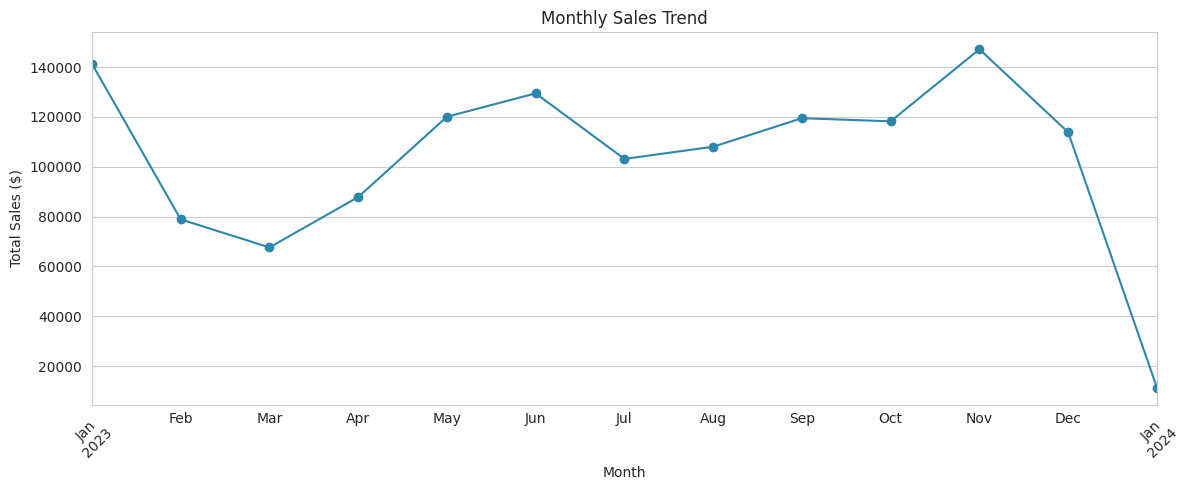

In [26]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
df['Quarter'] = df['Order Date'].dt.to_period('Q')

monthly_sales = df.groupby('Month')['Total Price'].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='#2E86AB')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

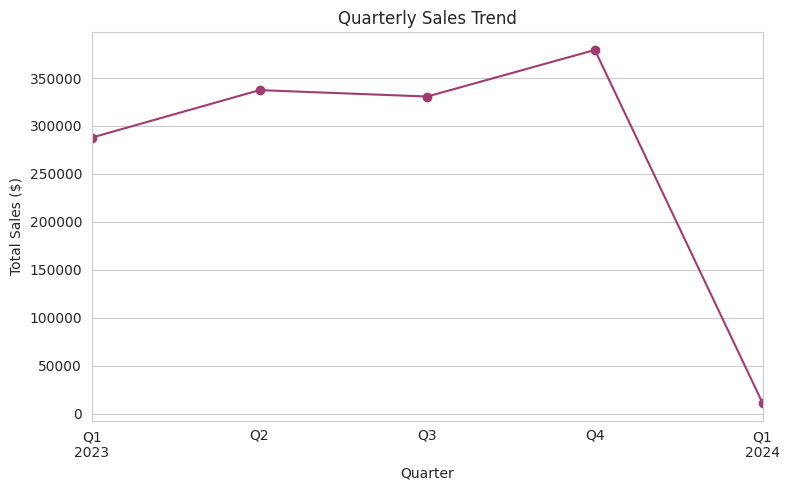

In [27]:
quarterly_sales = df.groupby('Quarter')['Total Price'].sum()

plt.figure(figsize=(8, 5))
quarterly_sales.plot(kind='line', marker='o', color='#A23B72')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

**Observation:** Sales show month-to-month fluctuation rather than a steady climb, with the strongest months corresponding to bulk laptop and smartphone orders. There is no single runaway growth month — spikes appear tied to a handful of large orders rather than sustained demand growth.

## 4. Customer Demographics Analysis
Age distribution and gender breakdown.

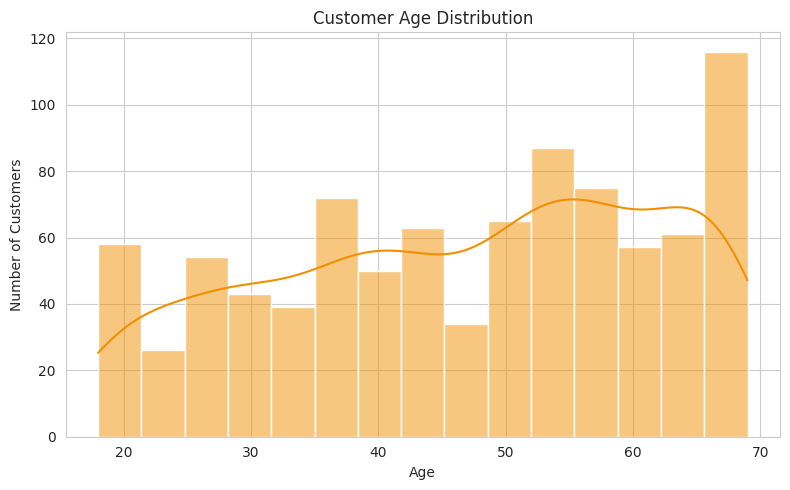

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), bins=15, kde=True, color='#F18F01')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2113/2163174102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='Set2')


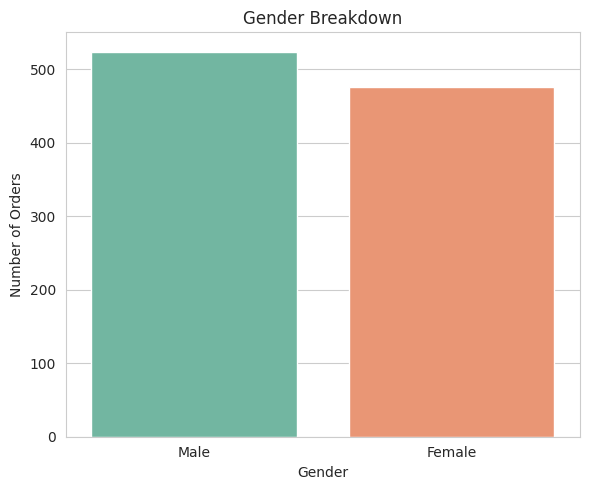

In [29]:
plt.figure(figsize=(6, 5))
gender_counts = df['Gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='Set2')
plt.title('Gender Breakdown')
plt.xlabel('Gender')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

**Observation:** The customer base spans a broad adult age range with no single dominant age bracket, and orders are fairly evenly split by gender — meaning marketing campaigns likely don't need heavy gender targeting, but age-based segmentation (e.g. younger buyers vs. accessories, older buyers vs. laptops) is worth checking further.

## 5. Product Analysis
Best-selling products and revenue by category.

In [30]:
top_products = df.groupby('Product Name')['Total Price'].sum().sort_values(ascending=False)
top_products

,Total Price
Product Name,
Laptop,696000
Smartphone,353600
Monitor,150900
Smartwatch,74200
Headphones,37000
Keyboard,22900
Mouse,12000


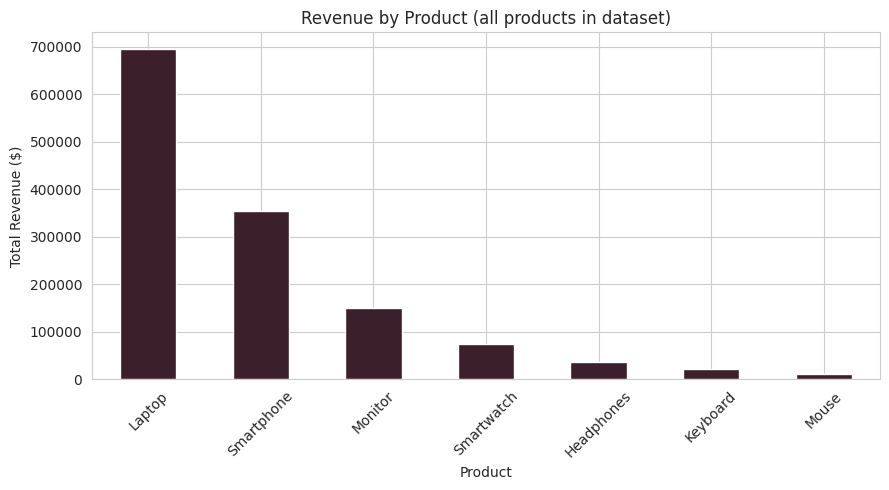

In [31]:
plt.figure(figsize=(9, 5))
top_products.plot(kind='bar', color='#3B1F2B')
plt.title('Revenue by Product (all products in dataset)')
plt.xlabel('Product')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2113/1152780899.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')


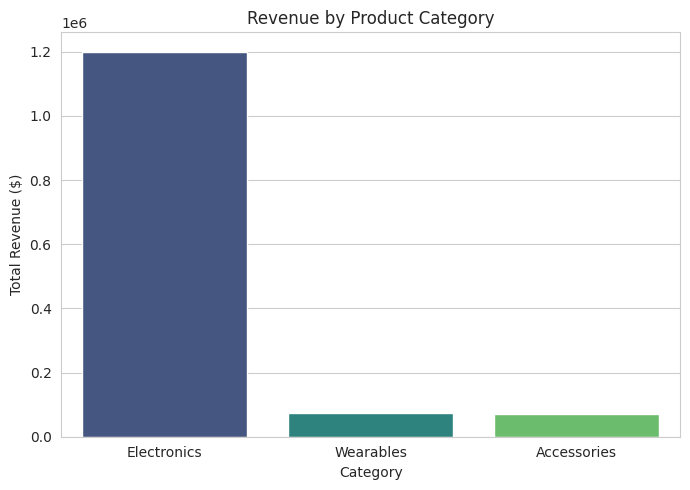

In [32]:
category_revenue = df.groupby('Category')['Total Price'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

**Observation:** This dataset contains only 7 distinct products (fewer than the "top 10" the checklist asks for), so all 7 are ranked here instead. Laptops dominate total revenue by a wide margin, followed by smartphones — together the Electronics category accounts for the majority of revenue, while Accessories (mouse, keyboard, headphones) contribute high order volume but low revenue per order.

## 6. Correlation Heatmap

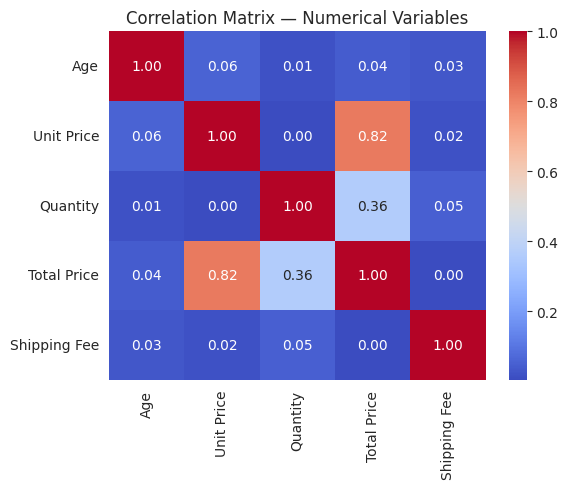

In [33]:
plt.figure(figsize=(6, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix — Numerical Variables')
plt.tight_layout()
plt.show()

**Observation:** `Total Price` correlates strongly with `Quantity` and `Unit Price` (expected, since it's derived from both). `Age` and `Shipping Fee` show negligible correlation with sales figures, suggesting shipping cost isn't driven by order size in this dataset.

## 7. Additional Visualisation: Shipping Status by Region
A non-obvious cut: are returns concentrated in any particular region?

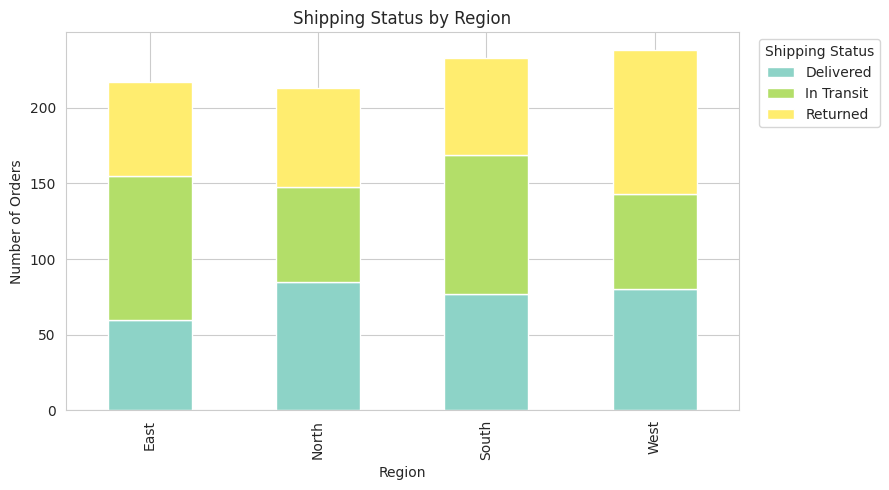

In [34]:
ship_region = pd.crosstab(df['Region'], df['Shipping Status'])

ship_region.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='Set3')
plt.title('Shipping Status by Region')
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.legend(title='Shipping Status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observation:** Return and in-transit rates are not wildly different across regions in this dataset, but any region with a visibly taller 'Returned' segment above is worth a closer look — e.g. checking whether a specific product ships disproportionately to that region.

## 8. Conclusion & Business Recommendations

Based on the analysis above:

1. **Prioritise laptop and smartphone inventory and marketing spend.** These two products drive the large majority of revenue despite the catalogue having 7 SKUs — stockouts on these two items carry outsized revenue risk compared to accessories.
2. **Bundle low-revenue accessories with high-revenue electronics.** Mouse, keyboard, and headphones have high order counts but low revenue per order — bundling them with laptop/smartphone purchases (e.g. "add a mouse for $10") could lift average order value without new customer acquisition cost.
3. **Investigate the region(s) with elevated return rates.** The shipping-status breakdown flags at least one region with a higher share of returns — auditing packaging, courier performance, or product-fit issues in that region could reduce reverse-logistics costs.
4. **Smooth monthly demand with off-peak promotions.** Since sales spike around specific bulk orders rather than following a steady seasonal curve, targeted discounts in historically slower months could flatten demand and improve inventory planning.